# Assignment-06

## A6Q1

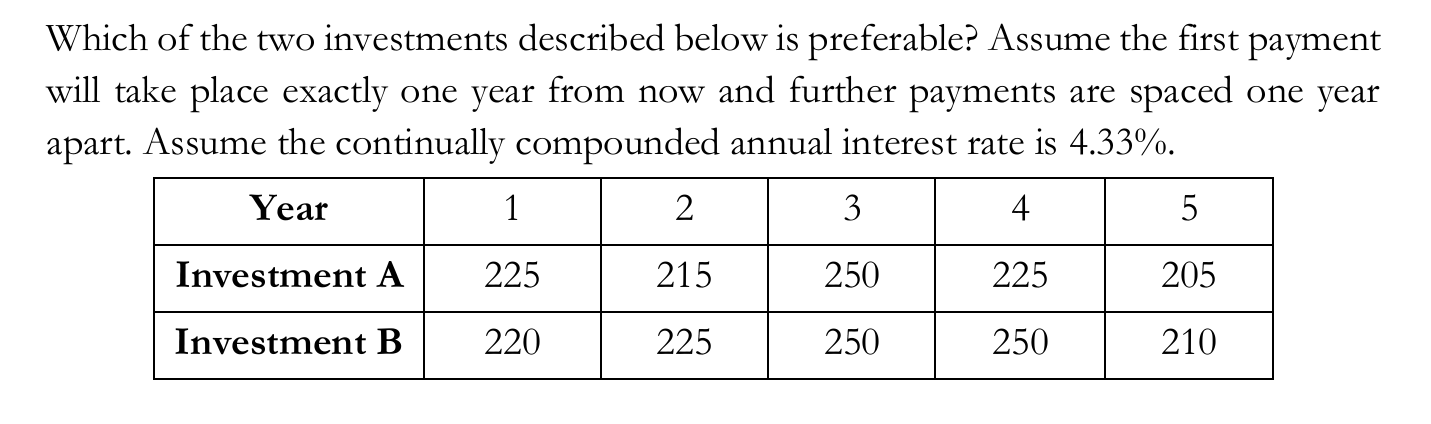

In [1]:
import numpy as np

r = 0.0433
years = np.arange(1, 6)

# Cash flows
A = np.array([225, 215, 250, 225, 205])
B = np.array([220, 225, 250, 250, 210])

PV_A=np.sum(A*np.exp(-r*years))
PV_B=np.sum(B*np.exp(-r*years))

print(f"Present Value of Investment A: {PV_A:.2f}")
print(f"Present Value of Investment B: {PV_B:.2f}")

print("Investment A is better." if PV_A > PV_B else "Investment B is better.")

Present Value of Investment A: 986.49
Present Value of Investment B: 1015.92
Investment B is better.


## A6Q2

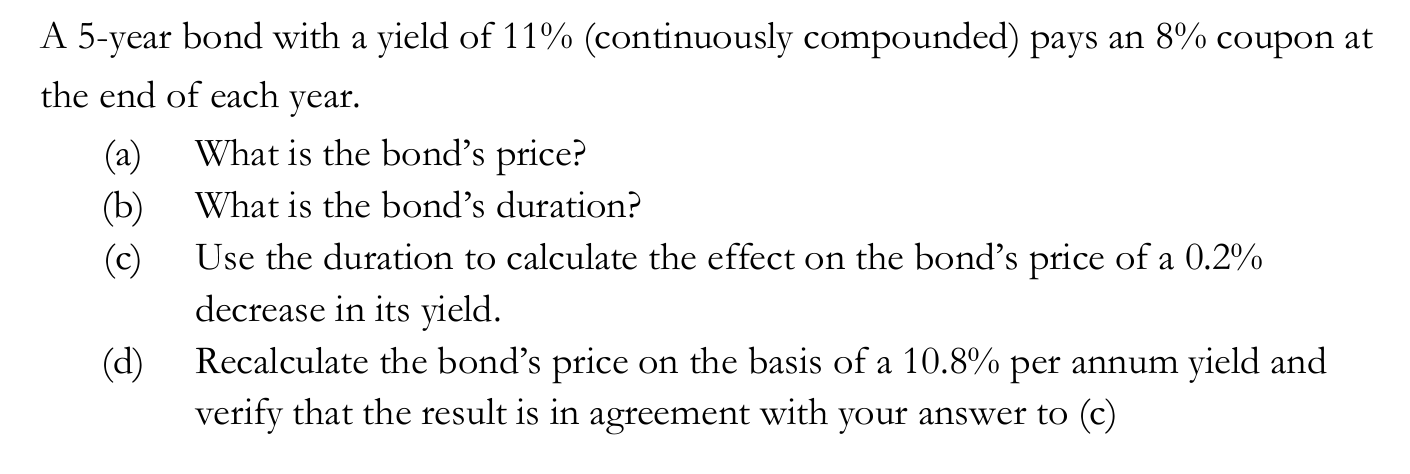

In [ ]:
import numpy as np

FV, c, r1, r2, n = 100, 0.08, 0.11, 0.108, 5
t = np.arange(1, n + 1)
cf = np.full(n, c * FV); cf[-1] += FV

P1 = np.sum(cf * np.exp(-r1 * t))
D = np.sum(t * cf * np.exp(-r1 * t)) / P1
P1_approx = P1 + D * P1 * 0.002
P2 = np.sum(cf * np.exp(-r2 * t))

print(P1, D, P1_approx, P2)

86.80108422328516 4.255974563427866 87.53993063634968 87.54339139534211


## A6Q3

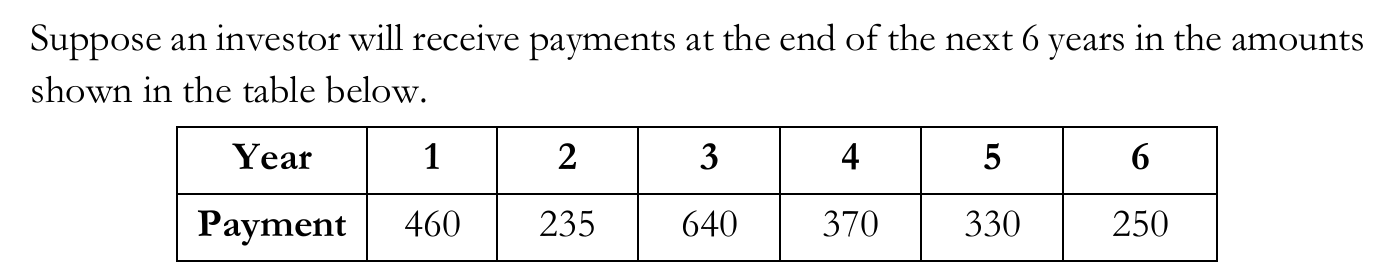
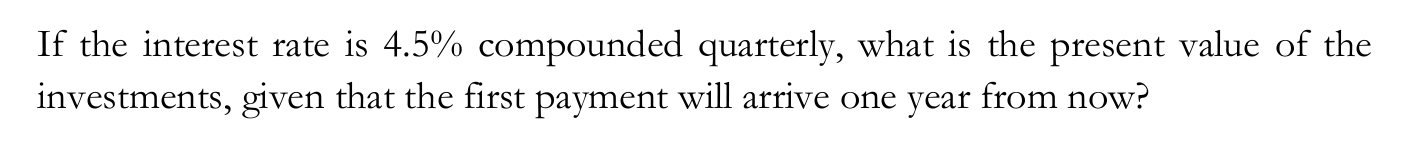

In [3]:
import numpy as np

P = np.array([460, 235, 640, 370, 330, 250])
i = 0.045
m = 4

PV=np.sum(P/(1+i/m)**(m*np.arange(1,7)))

print(f"Present Value: ${PV:.2f}")

Present Value: $1978.69


## A6Q4

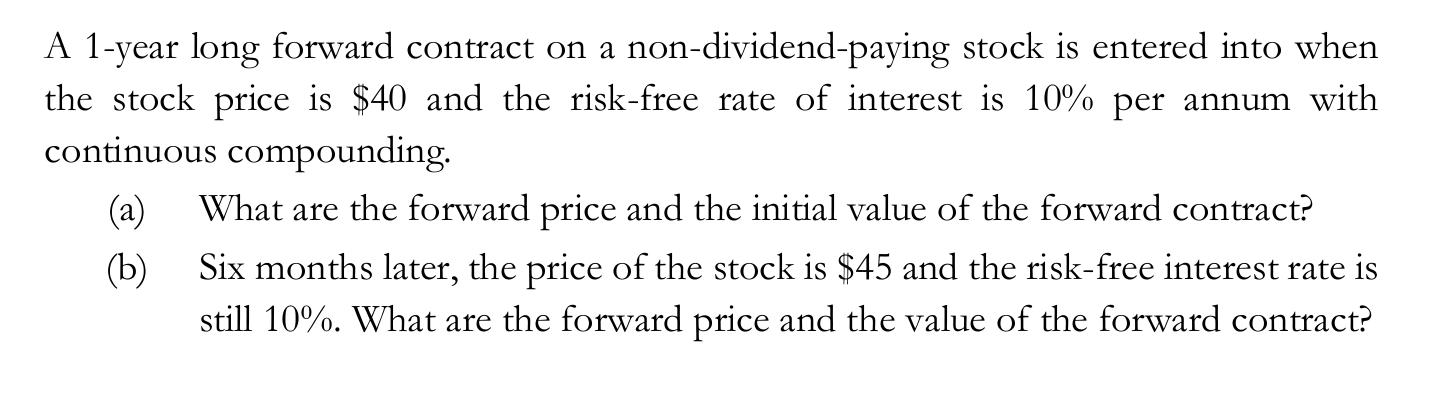

In [4]:
import numpy as np

S0, r, T = 40, 0.10, 1
F0 = S0 * np.exp(r * T)
print(f"F0={F0:.2f}, V0=0")

St, t = 45, 0.5
Vt = St - F0 * np.exp(-r * (T - t))     # ST - Present value of the prev Future value
Ft_new = St * np.exp(r * (T - t))
print(f"Ft={Ft_new:.2f}, Vt={Vt:.2f}")


F0=44.21, V0=0
Ft=47.31, Vt=2.95


## A6Q5

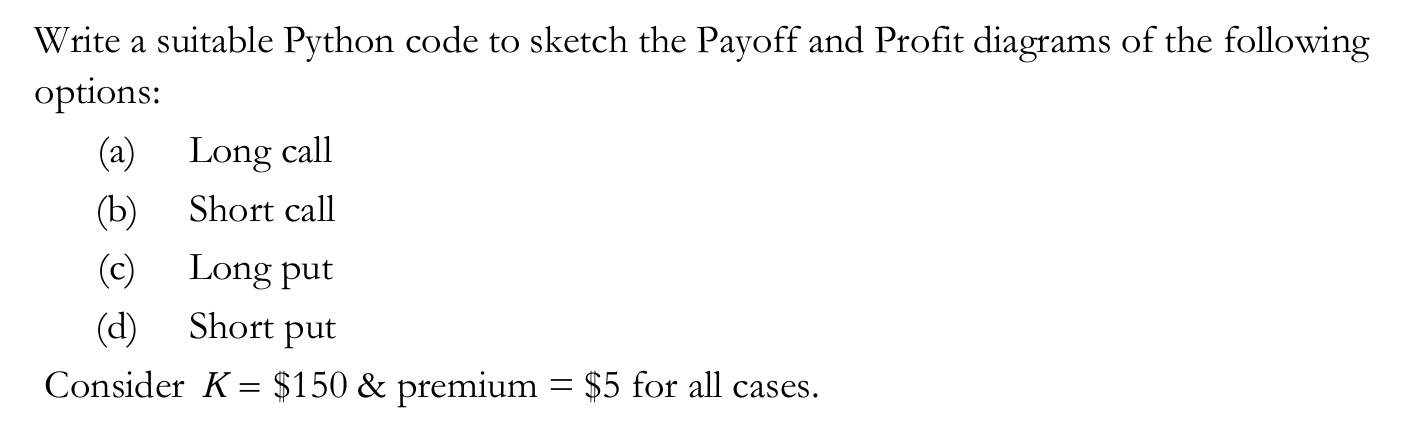

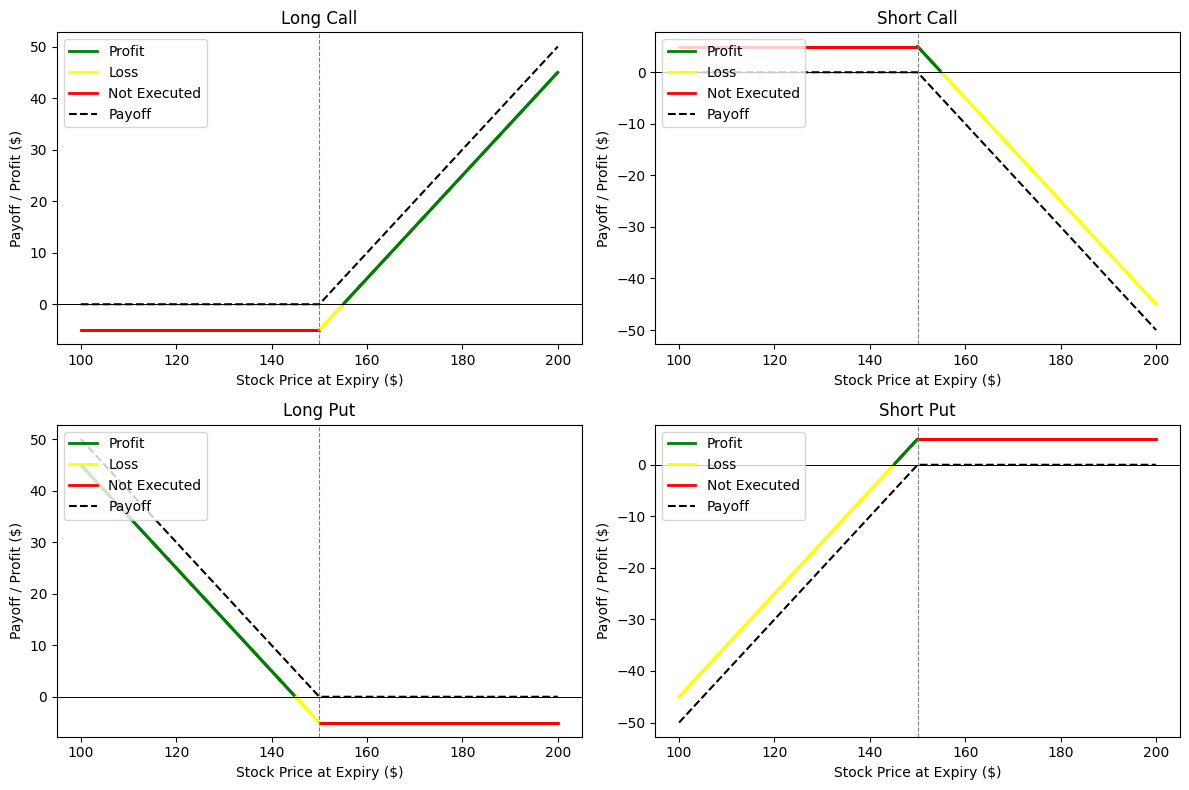

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Parameters
K = 150
premium = 5
S = np.linspace(100, 200, 500)

# Payoff and Profit functions
def calc_payoff_profit(option_type):
    if option_type == 'long_call':
        payoff = np.maximum(S - K, 0)
        profit = payoff - premium
    elif option_type == 'short_call':
        payoff = -np.maximum(S - K, 0)
        profit = payoff + premium
    elif option_type == 'long_put':
        payoff = np.maximum(K - S, 0)
        profit = payoff - premium
    elif option_type == 'short_put':
        payoff = -np.maximum(K - S, 0)
        profit = payoff + premium
    return payoff, profit

# Segment plotting
def plot_colored_line(ax, x, y, payoff, title):
    for i in range(len(x)-1):
        if payoff[i] == 0:
            color = 'red'     # Not executed
        elif y[i] < 0:
            color = 'yellow'  # Loss
        else:
            color = 'green'   # Profit
        ax.plot(x[i:i+2], y[i:i+2], color=color, linewidth=2)

    ax.plot(x, payoff, 'k--', linewidth=1.5, label='Payoff')
    ax.axhline(0, color='black', linewidth=0.7)
    ax.axvline(K, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('Stock Price at Expiry ($)')
    ax.set_ylabel('Payoff / Profit ($)')

    # Custom legend
    legend_elements = [
        Line2D([0], [0], color='green', lw=2, label='Profit'),
        Line2D([0], [0], color='yellow', lw=2, label='Loss'),
        Line2D([0], [0], color='red', lw=2, label='Not Executed'),
        Line2D([0], [0], color='black', linestyle='--', lw=1.5, label='Payoff')
    ]
    ax.legend(handles=legend_elements, loc='upper left')

# Plot all
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
titles = ['Long Call', 'Short Call', 'Long Put', 'Short Put']
types = ['long_call', 'short_call', 'long_put', 'short_put']

for ax, t, title in zip(axs.ravel(), types, titles):
    payoff, profit = calc_payoff_profit(t)
    plot_colored_line(ax, S, profit, payoff, title)

plt.tight_layout()
plt.show()


# A6Q6

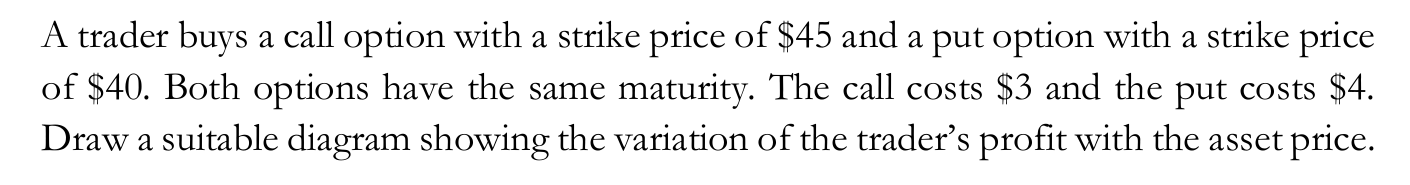

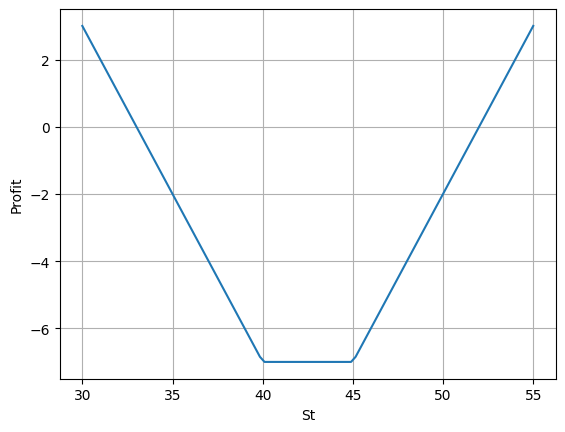

In [8]:
import numpy as np
import matplotlib.pyplot as plt

Kc=45;Kp=40;C=3;P=4

St=np.linspace(30,55,100)

Profit= np.maximum(St-Kc,0)-C+np.maximum(Kp-St,0)-P

# print(Profit)

plt.plot(St,Profit)
plt.xlabel("St")
plt.ylabel("Profit")
plt.grid()
plt.show()




## A6Q7

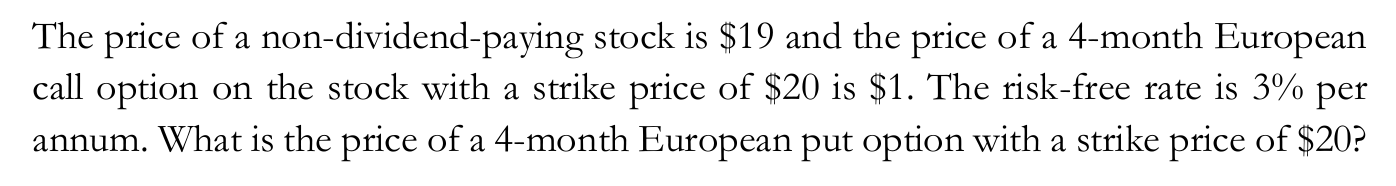

In [9]:
import numpy as np

St=19; K=20; C=1; r=0.03; t=4/12

P=C-St+K*np.exp(-r*t)

print(f"Put option price: {P}")

Put option price: 1.800996674983363


## A6Q8

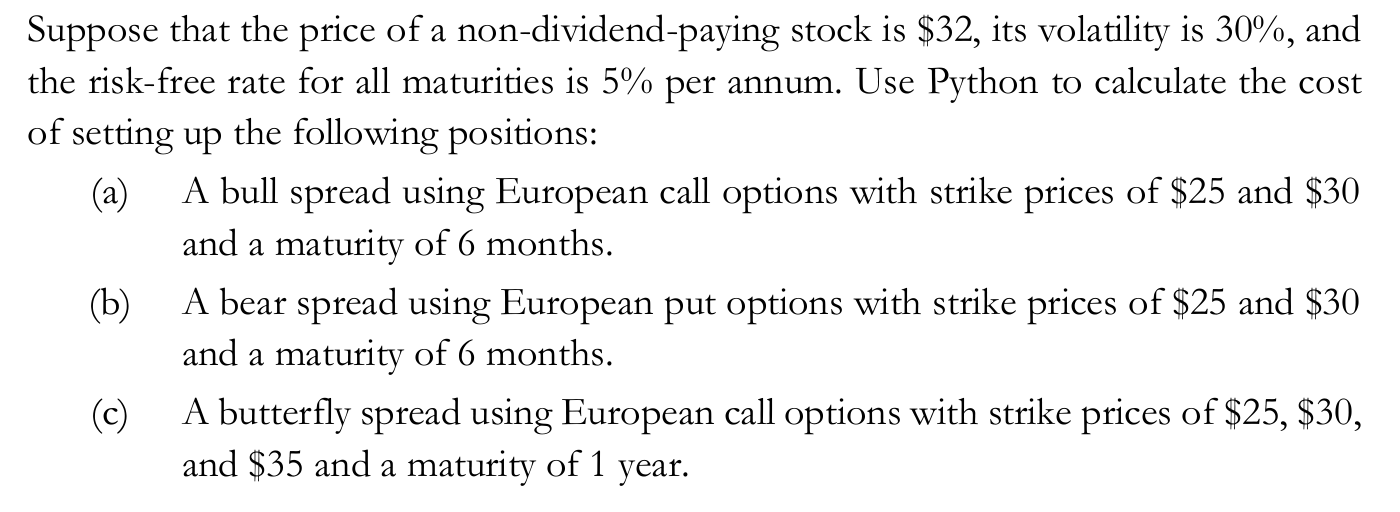
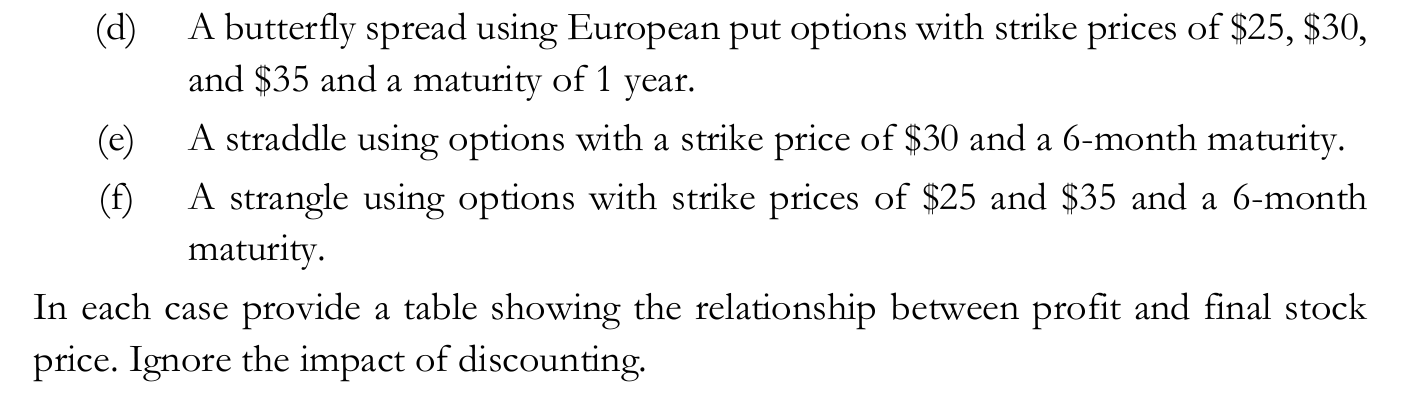

In [10]:
import mibian

S = 32 
r = 5                 # not 0.05
sigma = 30            # not 0.3
T1 = 0.5 * 365        #lol, days e input deya lage not year 
T2 = 1 * 365    

def CallPrice(S,K,r,T,Vol):
    return mibian.BS([S,K,r,T],volatility=Vol).callPrice

def PutPrice(S,K,r,T,Vol):
    return mibian.BS([S,K,r,T],volatility=Vol).putPrice


C25_6=CallPrice(S,25,r,T1,sigma)
C30_6=CallPrice(S,30,r,T1,sigma)
C35_6=CallPrice(S,35,r,T1,sigma)

P25_6=PutPrice(S,25,r,T1,sigma)
P30_6=PutPrice(S,30,r,T1,sigma)
P35_6=PutPrice(S,35,r,T1,sigma)


C25_12=CallPrice(S,25,r,T2,sigma)
C30_12=CallPrice(S,30,r,T2,sigma)
C35_12=CallPrice(S,35,r,T2,sigma)

P25_12=PutPrice(S,25,r,T2,sigma)
P30_12=PutPrice(S,30,r,T2,sigma)
P35_12=PutPrice(S,35,r,T2,sigma)

Bull_Cost=abs(C25_6-C30_6)
Bear_Cost=abs(P25_6-P30_6)
Butterfly1_Cost=abs(C25_12+C35_12-2*C30_12)
Butterfly2_Cost=abs(P25_12+P35_12-2*P30_12)
Long_Straddle_Cost=abs(C30_6+P30_6)         ########## same same but diff 
Long_Strangle_Cost=abs(P25_6+C35_6)         ########## aste rakho; jore dako


print(f"Bull Cost (call): {Bull_Cost}")
print(f"Bear Cost (put): {Bear_Cost}")
print(f"Butterfly Cost (call): {Butterfly1_Cost}")
print(f"Butterfly Cost (put): {Butterfly2_Cost}")
print(f"Long Straddle Cost: {Long_Straddle_Cost}")
print(f"Long Strangle Cost: {Long_Strangle_Cost}")



Bull Cost (call): 3.7129815835540576
Bear Cost (put): 1.16356797658761
Butterfly Cost (call): 1.0009096879706725
Butterfly Cost (put): 1.0009096879706725
Long Straddle Cost: 5.62672130157711
Long Strangle Cost: 2.1328040823930485


## A6Q9

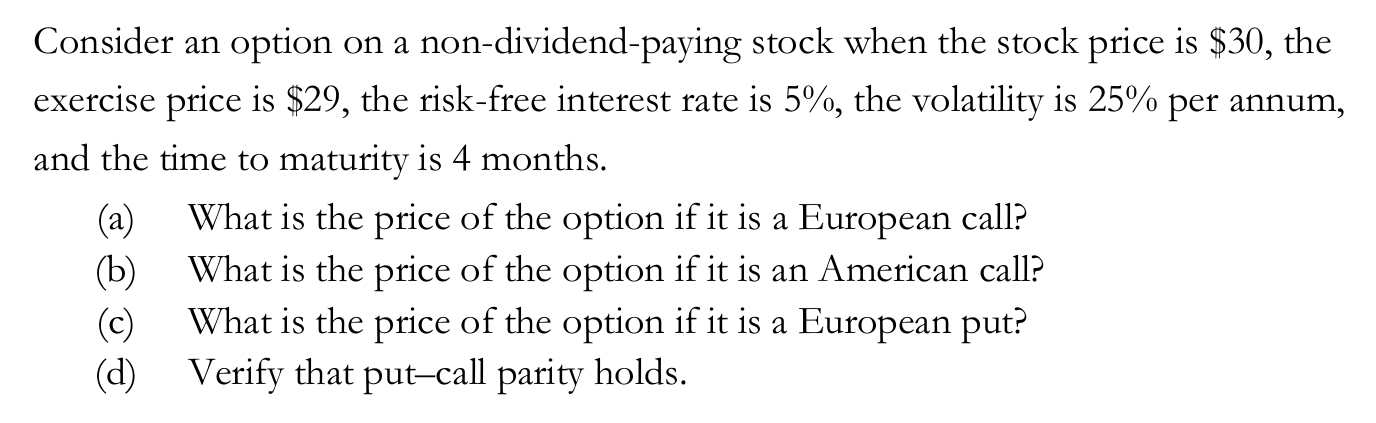

In [13]:
import mibian
import numpy as np

S=30; K=29; r=5; sigma=25; T=(4/12)*365

bs=mibian.BS([S,K,r,T],volatility=sigma)

EU_Call=bs.callPrice
US_Call=EU_Call       # same for non divident paying stock
EU_Put=bs.putPrice

PCP_Holds=abs(EU_Call-EU_Put - S + K*np.exp((-r/100)*(T/365)) ) <10**(-4)

print(f"EU_Call: {EU_Call} ;US_Call: {US_Call}; EU_Put: {EU_Put}")
print(f"Put Call er CHETONA Holds: {PCP_Holds}")


EU_Call: 2.5251469666999995 ;US_Call: 2.5251469666999995; EU_Put: 1.045819127526908
Put Call er CHETONA Holds: True


## A6Q10

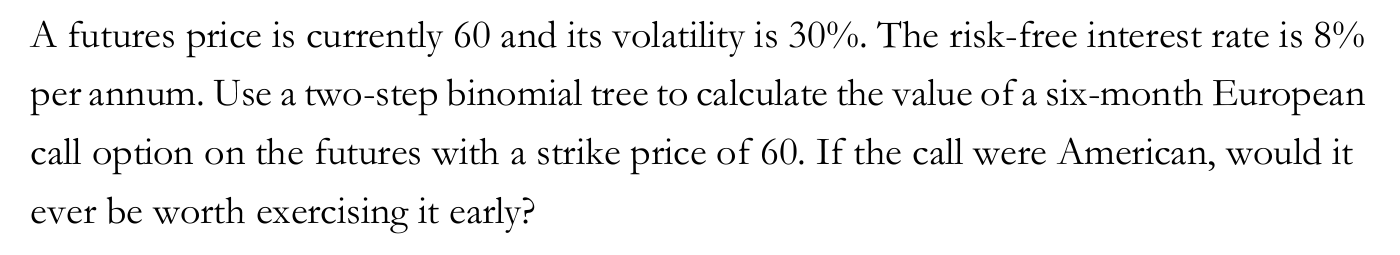

In [14]:
import numpy as np

S0=60; K=60; sigma=0.3; r=0.08; dt=3/12

u=np.exp(sigma*np.sqrt(dt))
d=1/u 

fuu=np.maximum(S0*u*u - K,0)
fud=np.maximum(S0*u*d - K,0)
fdd=np.maximum(S0*d*d - K,0)

p=(np.exp(r*dt)-d)/(u-d)
f=np.exp(-2*r*dt)*((p**2)*fuu + 2*p*(1-p)*fud + ((1-p)**2)*fdd  )


print(f"Value of EU Call: {f}")
print(f"Value of US Call == Value of EU Call: {f}; Cause, non divident paying stock")


Value of EU Call: 5.657964761441472
Value of US Call == Value of EU Call: 5.657964761441472; Cause, non divident paying stock


## A6Q11

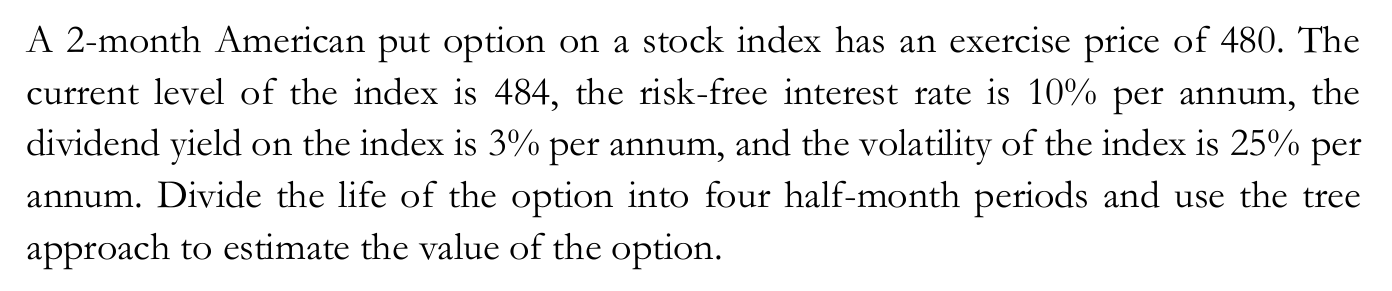

In [16]:
import numpy as np

S0=60; K=60; sigma=0.3; r=0.08; dt=3/12

u=np.exp(sigma*np.sqrt(dt))
d=1/u 

fuu=np.maximum(S0*u*u - K,0)
fud=np.maximum(S0*u*d - K,0)
fdd=np.maximum(S0*d*d - K,0)

p=(np.exp(r*dt)-d)/(u-d)
f=np.exp(-2*r*dt)*((p**2)*fuu + 2*p*(1-p)*fud + ((1-p)**2)*fdd  )


print(f"Value of EU Call: {f}")
print(f"Value of US Call == Value of EU Call: {f}; Cause, non divident paying stock")


Value of EU Call: 5.657964761441472
Value of US Call == Value of EU Call: 5.657964761441472; Cause, non divident paying stock
